# zagg read pipeline — HHDC tensors

Client-side reads of the SERC stores written in `02_write`: the photon t-digest store and the Sentinel-2 raster store (California follows once issue #370 lands). The reader stack is three libraries: **moczarr** (store discovery + spec-only decode — no zagg import on the byte path), **zagg** (the t-digest algebra), **mortie** (morton primitives).

In [1]:
# %pip install "moczarr>=0.3.0" "zagg[catalog,viz]"

import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from mortie import generate_morton_children
from moczarr.hhdc import read_tensors
from moczarr.open import open_hive, open_leaf
from moczarr.convention import morton_decimal
from moczarr.store import read_manifest

from zagg.catalog.shardmap import ShardMap
from zagg.config import default_config
from zagg.readers._layout import rank_to_rowcol, rowcol_to_rank
from zagg.readers.tdigest_tensor import cell_index, read_cell
from zagg.stats.tdigest import cdf_from_tdigest, quantile_from_tdigest

In [2]:
os.environ.setdefault("AWS_PROFILE", "nasa")
OUT = Path("outputs")
STORE = "s3://sliderule-public/zagg-demo"
TDIGEST = f"{STORE}/serc_tdigest.zarr"

timings = {}


class stage:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = round(time.perf_counter() - self.t0, 2)
        print(f"[{self.name}] {timings[self.name]:.1f}s")

## The whole store, one call (moczarr discovery)

Discovery is lazy: this prices *metadata only* — manifest, per-leaf stamps, and a morton index built arithmetically from the coverage MOC; zero digest bytes are fetched. The per-shard timings below measure the opposite layer: actually fetching, decoding, and rasterizing a leaf's data. Different layers of the stack, not two implementations of one read.

In [3]:
with stage("open_hive: discover + assemble"):
    ds = open_hive(TDIGEST)
ds

[open_hive: discover + assemble] 3.8s


<xarray.Dataset> Size: 117MB
Dimensions:    (cells: 4194304)
Coordinates:
  * morton     (cells) uint64 34MB 5347391238804865043 ... 5347413229033226259
    cell_ids   (cells) uint64 34MB 1000039514112 1000039514113 ... 1000044756991
Dimensions without coordinates: cells
Data variables:
    count      (cells) int32 17MB cubed.Array<chunksize=(4096,)>
    h_tdigest  (cells) object 34MB cubed.Array<chunksize=(4096,)>
Indexes:
    morton   MortonMocIndex(ranges=2, size=4194304)
Attributes:
    zarr_conventions:  [{'schema_url': 'https://raw.githubusercontent.com/zar...
    dggs:              {'name': 'morton', 'refinement_level': 19, 'spatial_di...
    morton_hive:       {'spec': 'morton-hive/1', 'cell_order': 19, 'shard_ord...

## Direct shard read → 128×128×64 tensors

One o12 block = 128×128 order-19 cells (~1.3 km square); 64 one-metre elevation bins. `read_tensors` visits only stored objects and yields `(tensor, mask, (offset, gain), morton)` per populated block — mask distinguishes unobserved / observed-empty / has-data.

In [4]:
sm = ShardMap.from_json(str(OUT / "shardmap_atl03_serc_o9.json"))
config = default_config("atl03_tdigest_healpix_hive")
(name,) = [n for n, m in config.aggregation["variables"].items() if m.get("kind") == "ragged"]
FIELD = f"{config.output['grid']['child_order']}/{name}"  # leaf arrays nest under the cell-order group

shard = max(zip((len(g) for g in sm.granules), (int(k) for k in sm.shard_keys)))[1]
store = open_leaf(TDIGEST, shard)

with stage("one shard: 128x128x64 tensor read"):
    blocks = list(
        read_tensors(store, FIELD, n_bins=64, resolution=1.0, block_order=12, fit="degrade_resolution")
    )
print(f"{len(blocks)} populated blocks; tensor shape {blocks[0][0].shape}")

[one shard: 128x128x64 tensor read] 8.6s
64 populated blocks; tensor shape (128, 128, 64)


In [5]:
pd.DataFrame(
    {
        "block": morton_decimal(word),
        "cells_with_data": int((mask == 2).sum()),
        "photons": int(tensor.sum()),
        "z_offset_m": round(offset, 1),
        "bin_m": gain,
    }
    for tensor, mask, (offset, gain), word in blocks
).set_index("block").sort_values("photons", ascending=False).head(10)

,cells_with_data,photons,z_offset_m,bin_m
block,,,,
4331422412232,2215,116852,-175.0,8.0
4331422412222,1691,110302,-367.0,16.0
4331422412234,2111,99050,-324.0,16.0
4331422412124,2341,97744,-222.0,8.0
4331422412332,1824,94883,-398.0,16.0
4331422412231,2180,92409,-321.0,16.0
4331422412224,2056,88088,-356.0,16.0
4331422412444,2168,82665,-352.0,16.0
4331422412424,1691,81128,-172.0,8.0


### One tensor, not 64

The sweep above bulk-reads every stored block. A `subtree=` read (zagg reader, spec §1.5) fetches only the chunks under one morton ancestor — the single-block price. (The moczarr twin is tracked as moczarr#29; until it lands, span-restricted reads come from zagg's reader.)

In [6]:
from zagg.readers.tdigest_tensor import read_tensors as zagg_read_tensors

_, _, _, word0 = max(blocks, key=lambda b: b[0].sum())
with stage("one tensor: subtree-restricted read"):
    ((t1, m1, (o1, g1), w1),) = zagg_read_tensors(
        store, FIELD, subtree=int(word0),
        n_bins=64, resolution=1.0, block_order=12, fit="degrade_resolution",
    )
print(f"single block {morton_decimal(w1)}: {int(t1.sum()):,} photons -- "
      f"vs the full-shard sweep for all 64 blocks above")

[one tensor: subtree-restricted read] 1.4s
single block 4331422412232: 116,852 photons -- vs the full-shard sweep for all 64 blocks above


## Combined vs signal stratum — why the split exists

The combined digest's z-window is noise-dominated (solar background over hundreds of metres), so `fit="degrade_resolution"` stretched the 64 bins to 8–16 m. The strata store's `h_tdigest_signal` field holds only confidence-selected photons — same shard, same cells, and the window collapses to the terrain + canopy envelope.

In [7]:
STRATA = f"{STORE}/serc_tdigest_strata.zarr"
FIELD_SIG = f"{config.output['grid']['child_order']}/h_tdigest_signal"

with stage("signal stratum: same shard, same blocks"):
    blocks_sig = list(
        read_tensors(open_leaf(STRATA, shard), FIELD_SIG,
                     n_bins=64, resolution=1.0, block_order=12, fit="degrade_resolution")
    )


def window_summary(bs, tag):
    return pd.DataFrame(
        {"block": morton_decimal(w), f"bin_m ({tag})": g, f"z0_m ({tag})": round(off, 1),
         f"photons ({tag})": int(t.sum())}
        for t, m, (off, g), w in bs
    ).set_index("block")


cmp = window_summary(blocks, "combined").join(window_summary(blocks_sig, "signal"))
cmp.sort_values("photons (combined)", ascending=False).head(8)

[signal stratum: same shard, same blocks] 5.1s


,bin_m (combined),z0_m (combined),photons (combined),bin_m (signal),z0_m (signal),photons (signal)
block,,,,,,
4331422412232,8.0,-175.0,116852,1.0,-44.0,80815
4331422412222,16.0,-367.0,110302,8.0,-43.0,46200
4331422412234,16.0,-324.0,99050,2.0,-45.0,40149
4331422412124,8.0,-222.0,97744,2.0,-58.0,53328
4331422412332,16.0,-398.0,94883,4.0,-140.0,29013
4331422412231,16.0,-321.0,92409,2.0,-43.0,48980
4331422412224,16.0,-356.0,88088,2.0,-56.0,54032
4331422412444,16.0,-352.0,82665,4.0,-117.0,40207


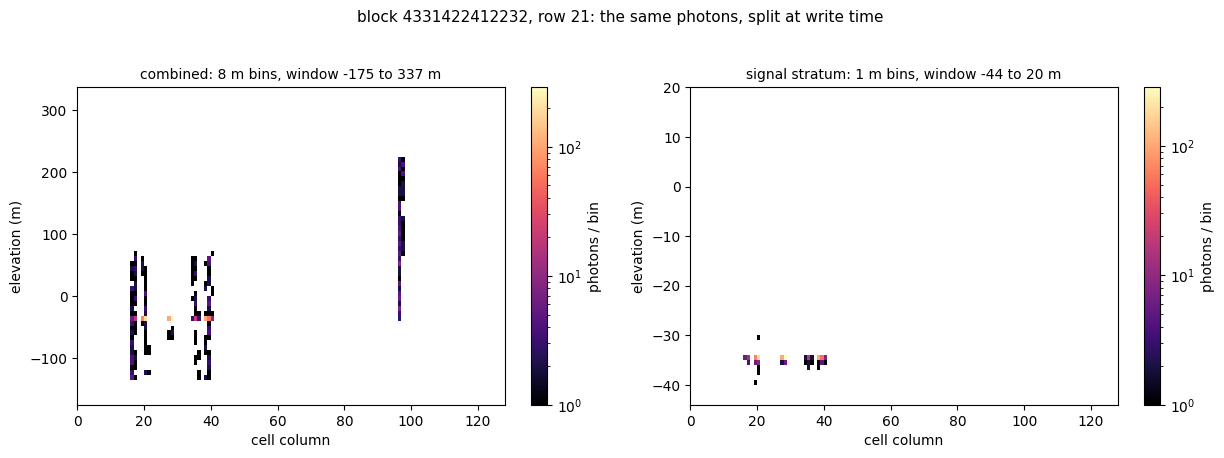

In [8]:
tc, mc, (oc, gc), wc = max(blocks, key=lambda b: b[0].sum())
ts, ms, (osig, gsig), _ = next(b for b in blocks_sig if b[3] == wc)
r = int(tc.sum(axis=(1, 2)).argmax())  # the block's densest row -> a 128-cell curtain

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, (t, off, g, label) in zip(
    axes, [(tc, oc, gc, "combined"), (ts, osig, gsig, "signal stratum")]
):
    cur = t[r].T.astype("float64")
    cur[cur == 0] = np.nan
    im = ax.imshow(cur, origin="lower", aspect="auto", cmap="magma", norm=LogNorm(vmin=1),
                   extent=[0, 128, off, off + 64 * g])
    ax.set_title(f"{label}: {g:g} m bins, window {off:.0f} to {off + 64 * g:.0f} m", fontsize=10)
    ax.set_xlabel("cell column")
    ax.set_ylabel("elevation (m)")
    fig.colorbar(im, ax=ax, label="photons / bin")
fig.suptitle(f"block {morton_decimal(wc)}, row {r}: the same photons, split at write time", y=1.03, fontsize=11)
plt.tight_layout()

## An iterator from (shardmap, template)

The shardmap enumerates the leaves; the aggregation template names the ragged field — that pair is enough to stream every HHDC block of a store.

In [9]:
def iter_hhdc(store_root, shardmap, config, **kwargs):
    """Yield (shard, tensor, mask, (offset, gain), morton) across a shardmap's leaves."""
    (name,) = [n for n, m in config.aggregation["variables"].items() if m.get("kind") == "ragged"]
    field = f"{config.output['grid']['child_order']}/{name}"
    manifest = read_manifest(store_root)  # once; open_leaf skips its per-leaf GET
    for k in shardmap.shard_keys:
        leaf_store = open_leaf(store_root, int(k), manifest=manifest)
        for tensor, mask, scale, word in read_tensors(leaf_store, field, **kwargs):
            yield int(k), tensor, mask, scale, word

In [10]:
rows = []
with stage("all shards: HHDC sweep"):
    for k, tensor, mask, (offset, gain), word in iter_hhdc(
        TDIGEST, sm, config, n_bins=64, resolution=1.0, block_order=12, fit="degrade_resolution"
    ):
        rows.append({"shard": morton_decimal(int(k)), "block": morton_decimal(word), "cells": int((mask == 2).sum()), "photons": int(tensor.sum())})
sweep = pd.DataFrame(rows)
print(f"{len(sweep)} blocks, {sweep.photons.sum() / 1e6:.1f}M photons across {sweep.shard.nunique()} shards")
sweep.groupby("shard")[["cells", "photons"]].sum()

[all shards: HHDC sweep] 30.6s
256 blocks, 20.9M photons across 4 shards


,cells,photons
shard,,
4331422411,115964,5800359
4331422412,104941,3738213
4331422414,111213,6241989
4331422421,85204,5142678


## Percentile surfaces from the tensor

Binned counts cumsum along z → any percentile height per cell, pure numpy — ground (p05), median energy, canopy top (p98), and their difference is a canopy-height model.

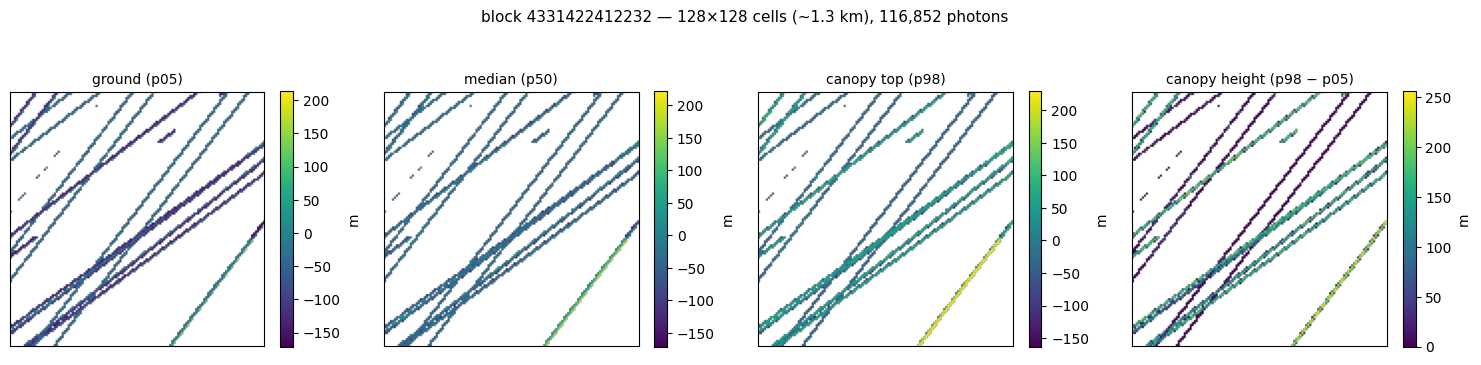

In [11]:
def percentile_height(tensor, mask, offset, gain, q):
    counts = tensor.astype("float64")
    total = counts.sum(axis=2)
    idx = (counts.cumsum(axis=2) >= q * total[..., None]).argmax(axis=2)
    return np.where((mask == 2) & (total > 0), offset + (idx + 0.5) * gain, np.nan)


tensor, mask, (offset, gain), word = max(blocks, key=lambda b: b[0].sum())

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
p05 = percentile_height(tensor, mask, offset, gain, 0.05)
p98 = percentile_height(tensor, mask, offset, gain, 0.98)
panels = [(p05, "ground (p05)"), (percentile_height(tensor, mask, offset, gain, 0.50), "median (p50)"),
          (p98, "canopy top (p98)"), (p98 - p05, "canopy height (p98 − p05)")]
for ax, (surf, title) in zip(axes, panels):
    im = ax.imshow(surf, origin="lower", cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]), ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.85, label="m")
fig.suptitle(f"block {morton_decimal(word)} — 128×128 cells (~1.3 km), {int(tensor.sum()):,} photons", y=1.04, fontsize=11)
plt.tight_layout()

## One column → waveform and PDF

A t-digest is a mixture representation: the smooth waveform is the centroid mixture (no photon reconstruction), the bars are the binned tensor column, and the quantile lines come from zagg's digest algebra. The cell's exact digest is fetched with the 2-GET random-access path.

In [12]:
from ipywidgets import Checkbox, Dropdown, IntSlider, interact

worder = sorted(range(len(blocks)), key=lambda i: -int(blocks[i][0].sum()))
woptions = [
    (f"{morton_decimal(blocks[i][3])}  ({int(blocks[i][0].sum()):,} photons)", i) for i in worder
]


_pin = next((i for i in worder if morton_decimal(blocks[i][3]) == "4331422412231"), worder[0])


def waveform(block=_pin, nth=21):
    t, m, (off, g), w = blocks[block]
    pick = int(np.argsort(t.sum(axis=2).ravel())[::-1][nth])
    r, c = np.unravel_index(pick, t.shape[:2])
    chunk_id = int(generate_morton_children(int(w), 13)[rowcol_to_rank(r // 64, c // 64, depth=1)])
    digest = read_cell(store, FIELD, cell_index(store, FIELD, chunk_id, int(r % 64), int(c % 64)))
    mu, wt = digest[:, 0], digest[:, 1]

    z = np.linspace(off, off + 64 * g, 600)
    sigma = g  # pulse-width smoothing kernel, one bin
    pdf = (wt[None, :] * np.exp(-0.5 * ((z[:, None] - mu[None, :]) / sigma) ** 2)).sum(axis=1)
    pdf /= wt.sum() * sigma * np.sqrt(2 * np.pi)
    col = t[r, c].astype(float)
    centers = off + (np.arange(64) + 0.5) * g

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
    ax1.barh(centers, col, height=g * 0.9, color="#4269d0", alpha=0.55, label="binned counts")
    ax1.plot(pdf * col.sum() * g, z, color="#1f2d3d", lw=1.8, label="digest mixture waveform")
    for q, ls in ((0.05, ":"), (0.50, "--"), (0.98, ":")):
        ax1.axhline(quantile_from_tdigest(digest, q), color="#e4572e", lw=1.2, ls=ls)
    ax1.set_xlabel("photons / bin")
    ax1.set_ylabel("elevation (m)")
    merged = wt > 1
    ax1.set_title(
        f"cell (row {r}, col {c}): {wt.sum():.0f} obs \u2192 {len(wt)} centroids\n"
        f"{int((~merged).sum())} lossless + {int(merged.sum())} merged "
        f"({wt[merged].sum() / max(wt.sum(), 1) * 100:.1f}% of obs compressed)", fontsize=9
    )
    ax1.legend(fontsize=8, loc="upper right")
    ax2.plot(cdf_from_tdigest(digest, z), z, color="#4269d0", lw=2)
    ax2.set_xlabel("CDF")
    ax2.set_title("probability distribution", fontsize=10)
    for ax in (ax1, ax2):
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25, lw=0.5)
    plt.tight_layout()
    plt.show()


interact(waveform, block=Dropdown(options=woptions, value=_pin, description="block"),
         nth=IntSlider(min=0, max=30, value=21, description="nth densest"))

interactive(children=(Dropdown(description='block', index=5, options=(('4331422412232  (116,852 photons)', 25)…

<function __main__.waveform(block=24, nth=6)>

## Height surfaces at PDF percentile thresholds

In [13]:
qs = (0.05, 0.25, 0.50, 0.75, 0.98)
fig, axes = plt.subplots(1, len(qs), figsize=(16, 3.2), sharey=True)
for ax, q in zip(axes, qs):
    im = ax.imshow(percentile_height(tensor, mask, offset, gain, q), origin="lower", cmap="viridis")
    ax.set_title(f"p{int(q * 100):02d}", fontsize=10)
    ax.set_xticks([]), ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label="elevation (m)")

## Tensor explorer

Signal-stratum blocks (sorted by occupied cells) — walk the elevation bins; each option lists its vertical step, and empty/unobserved cells render transparent.

In [14]:
from ipywidgets import Dropdown, IntSlider, interact

order = sorted(range(len(blocks_sig)), key=lambda i: -int((blocks_sig[i][1] == 2).sum()))
options = [
    (f"{morton_decimal(blocks_sig[i][3])}  ({int((blocks_sig[i][1] == 2).sum())} cells, "
     f"{int(blocks_sig[i][0].sum()):,} photons, {blocks_sig[i][2][1]:g} m bins)", i)
    for i in order
]
_pin_x = next((i for i in order if morton_decimal(blocks_sig[i][3]) == "4331422412231"), order[0])
# ONE norm across every block and slice: the frame, ticks, and colorbar never move
_VMAX = float(max(b[0].max() for b in blocks_sig))


def z_slice(block=_pin_x, z=32):
    t, m, (off, g), w = blocks_sig[block]  # signal stratum
    sl = t[:, :, z].astype("float64")
    sl[(m != 2) | (sl == 0)] = np.nan  # empty bins + unobserved cells -> transparent

    fig, ax = plt.subplots(figsize=(6.8, 5.4))
    fig.subplots_adjust(left=0.10, right=0.90, top=0.90, bottom=0.10)  # pinned frame
    ax.set_facecolor("#e8e8e8")
    im = ax.imshow(sl, origin="lower", cmap="magma", norm=LogNorm(vmin=1, vmax=_VMAX),
                   extent=(-0.5, 127.5, -0.5, 127.5))
    ax.set_xlim(-0.5, 127.5)
    ax.set_ylim(-0.5, 127.5)
    ax.set_xticks([0, 32, 64, 96, 127])
    ax.set_yticks([0, 32, 64, 96, 127])
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.set_title(
        f"{morton_decimal(w)} — bin {z:02d}: {off + z * g:+8.1f} to {off + (z + 1) * g:+8.1f} m "
        f"({g:g} m step, {int(np.nansum(sl)):>7,} photons)", fontsize=10
    )
    fig.colorbar(im, ax=ax, label="photons / bin", fraction=0.046, pad=0.03)
    plt.show()


interact(z_slice, block=Dropdown(options=options, value=_pin_x, description="block"),
         z=IntSlider(min=0, max=63, value=32, description="z bin"))

interactive(children=(Dropdown(description='block', options=(('4331422412433  (1935 cells, 26,995 photons, 4 m…

<function __main__.z_slice(block=58, z=32)>

The whole block in 3-D — drag to rotate (ipympl backend); empty bins are transparent by omission.

In [15]:
%matplotlib widget

FIELD_NOISE = f"{config.output['grid']['child_order']}/h_tdigest_noise"
with stage("noise stratum: same shard"):
    blocks_noise = list(
        read_tensors(open_leaf(STRATA, shard), FIELD_NOISE,
                     n_bins=64, resolution=1.0, block_order=12, fit="degrade_resolution")
    )
_sig = {w: (t, off, g) for t, m, (off, g), w in blocks_sig}
_noi = {w: (t, off, g) for t, m, (off, g), w in blocks_noise}


def _pts(t, off, g, cap=25000):
    xs, ys, zs = np.nonzero(t)
    counts = t[xs, ys, zs].astype("float64")
    if len(xs) > cap:  # keep drag-rotation fluid
        keep = np.random.default_rng(0).choice(len(xs), cap, replace=False)
        xs, ys, zs, counts = xs[keep], ys[keep], zs[keep], counts[keep]
    return xs, ys, off + zs * g, counts


def view3d(block=_pin_x, signal=True, noise=False):
    w = blocks_sig[block][3]
    fig = plt.figure(figsize=(7.5, 6))
    ax = fig.add_subplot(projection="3d")
    pts = None
    if signal and w in _sig:
        xs, ys, zz, counts = _pts(*_sig[w])
        pts = ax.scatter(xs, ys, zz, c=counts, s=1.5, cmap="viridis", norm=LogNorm(),
                         alpha=np.clip(counts / np.percentile(counts, 98), 0.1, 1.0))
    if noise and w in _noi:
        xs, ys, zz, _counts = _pts(*_noi[w])
        ax.scatter(xs, ys, zz, color="#9498a0", s=1.0, alpha=0.06)
    ax.set_zlabel("elevation (m)")
    ax.set_title(f"{morton_decimal(w)} — signal={signal}, noise={noise}", fontsize=10)
    ax.set_xticks([]), ax.set_yticks([])
    if pts is not None:
        fig.colorbar(pts, shrink=0.6, pad=0.1, label="signal photons / bin")
    plt.show()


interact(view3d, block=Dropdown(options=options, value=_pin_x, description="block"),
         signal=Checkbox(value=True, description="signal"),
         noise=Checkbox(value=False, description="noise"))

[noise stratum: same shard] 5.5s


interactive(children=(Dropdown(description='block', options=(('4331422412433  (1935 cells, 26,995 photons, 4 m…

<function __main__.view3d(block=58, signal=True, noise=False)>

In [ ]:
%matplotlib inline
# static figures below revert to the inline backend

## Sentinel-2 over the same cells

The S2 store shares the o19 cells axis with the photon store, so co-registration to the HHDC block is index arithmetic — no reprojection, no resampling. Pick the clearest 2025 datatake by SCL cloud fraction, then compare the optical view with the lidar canopy-height model over the identical 128×128 cells.

In [ ]:
S2 = f"{STORE}/s2_serc_2025.zarr"
with stage("open_hive: S2 (time, cells) store"):
    s2 = open_hive(S2)
s2

In [ ]:
# the SAME o12 block as the HHDC sections: its o19 cells are one contiguous
# nested-order span, located in the cells axis by morton value (mortie)
children = generate_morton_children(int(word), 19)
lo, hi = np.searchsorted(s2.morton.values, [int(children[0]), int(children[-1])])
sl = slice(lo, hi + 1)
def to_image(values_1d, depth=7):
    """Nested-order cell values -> spatially faithful 2-D image (spec §8 deinterleave)."""
    side = 2**depth
    img = np.empty((side, side), dtype=values_1d.dtype)
    r, c = rank_to_rowcol(np.arange(side * side), depth)
    img[r, c] = values_1d
    return img


with stage("S2: cloud screen + block read"):
    scl_block = s2.scl.isel(cells=sl).values  # (time, 16384)
    cloud_frac = np.isin(scl_block, (3, 8, 9, 10)).mean(axis=1)
    t = int(np.argmin(cloud_frac))
    rgb = np.stack(
        [to_image(s2[b].isel(time=t, cells=sl).values) for b in ("red", "green", "blue")], axis=-1
    )
    nir = to_image(s2.nir.isel(time=t, cells=sl).values).astype("float64")
print(f"clearest datatake: index {t} ({cloud_frac[t] * 100:.1f}% cloudy)")

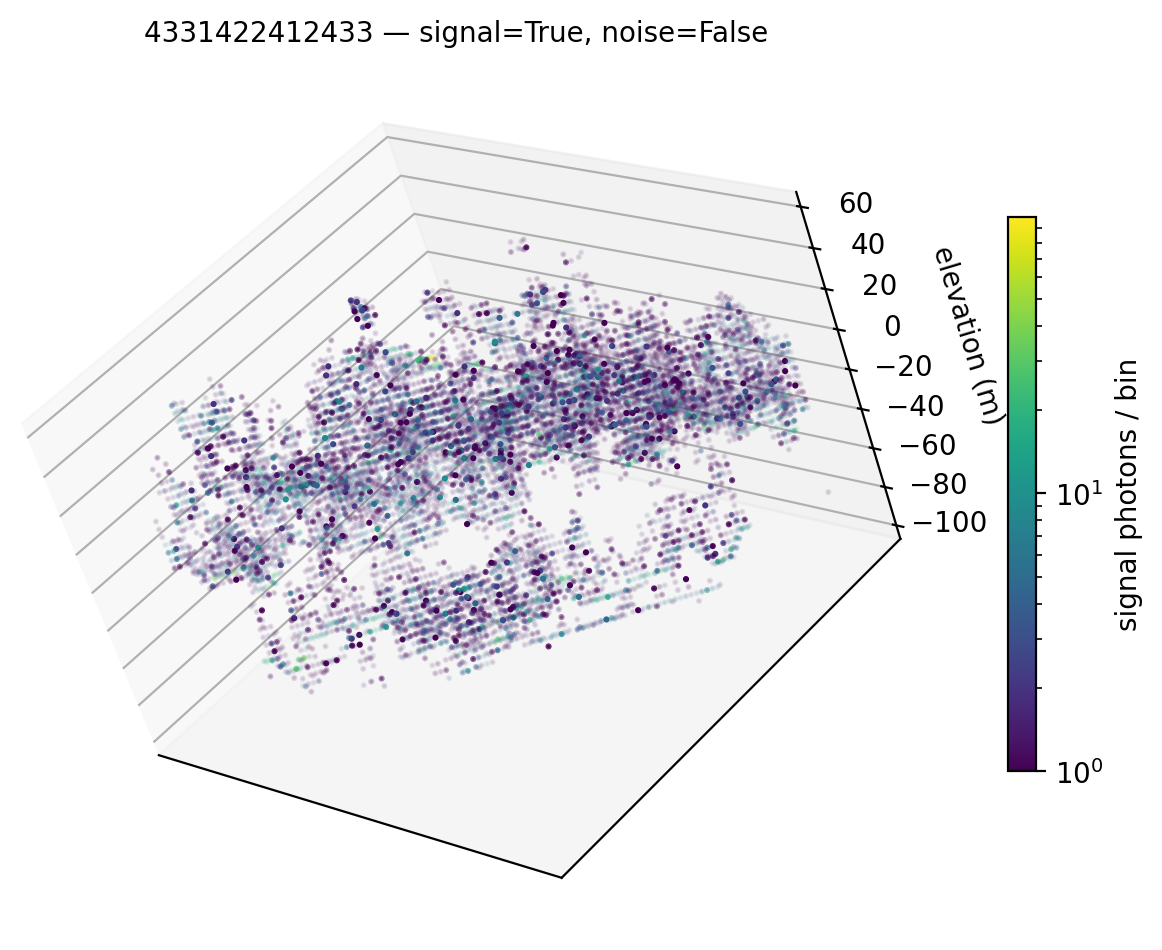

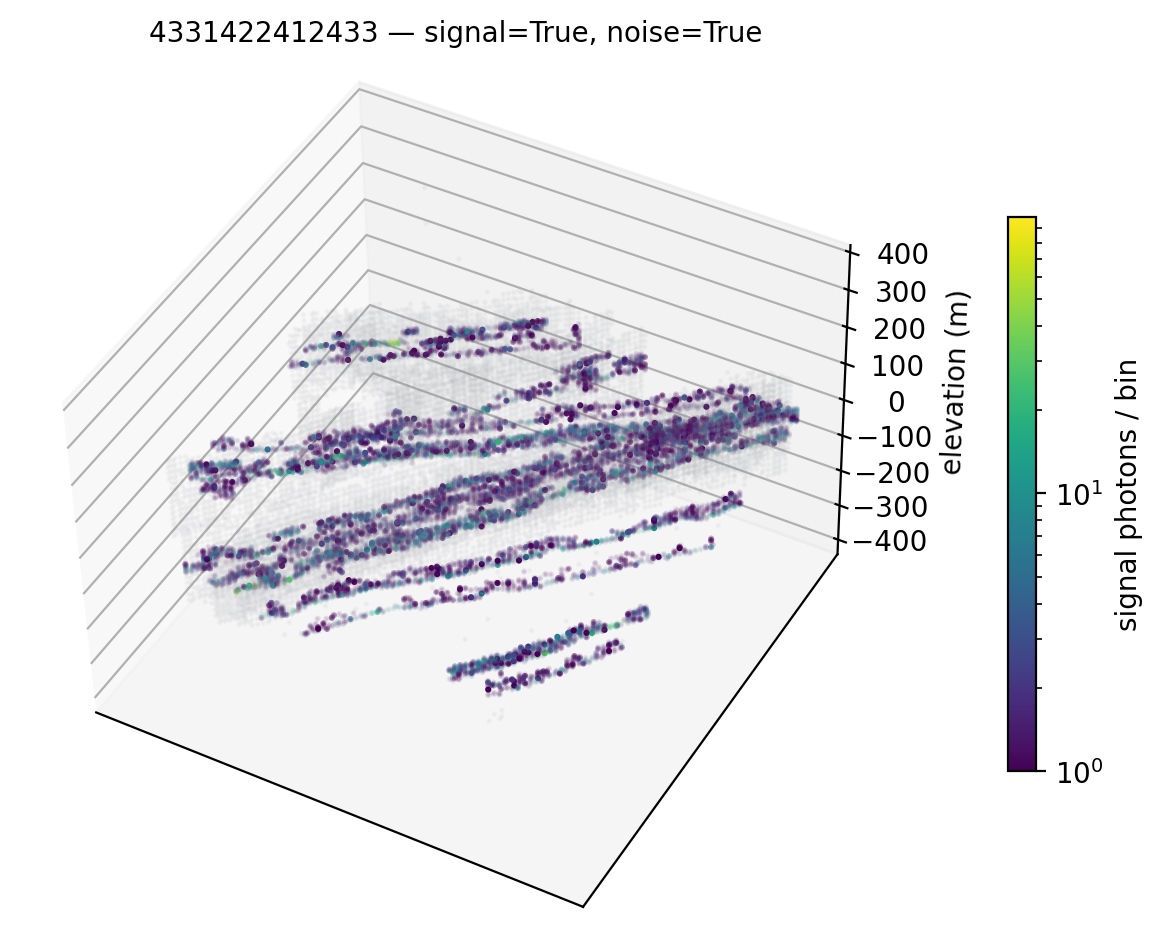

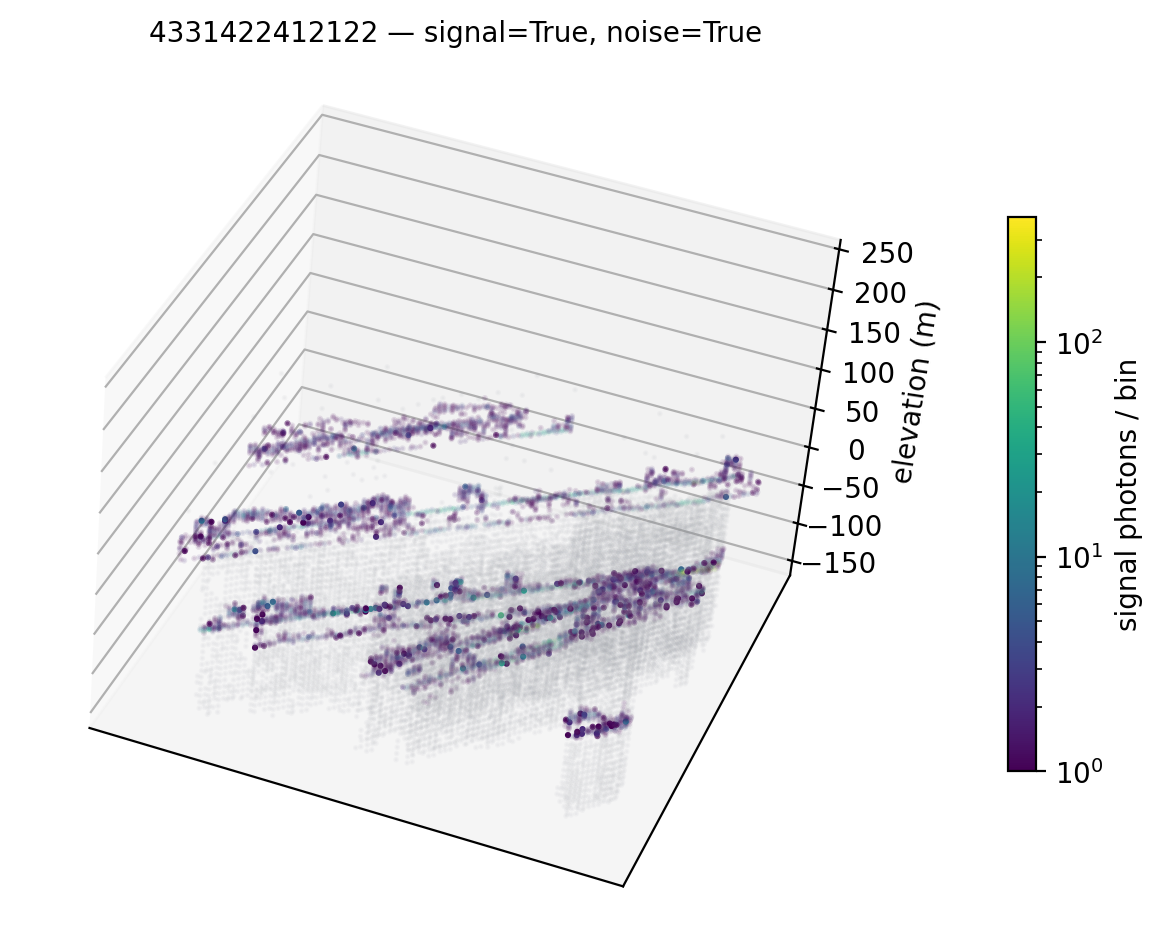

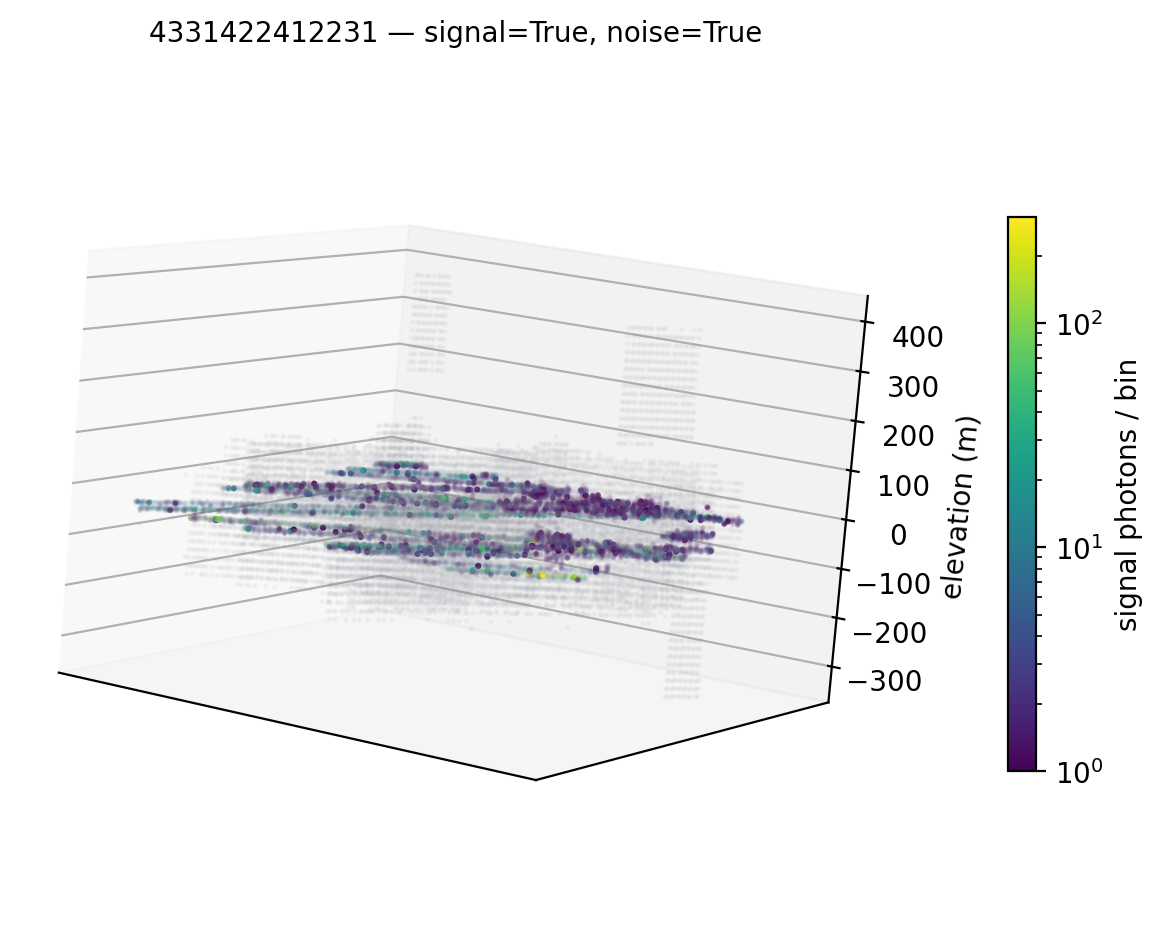

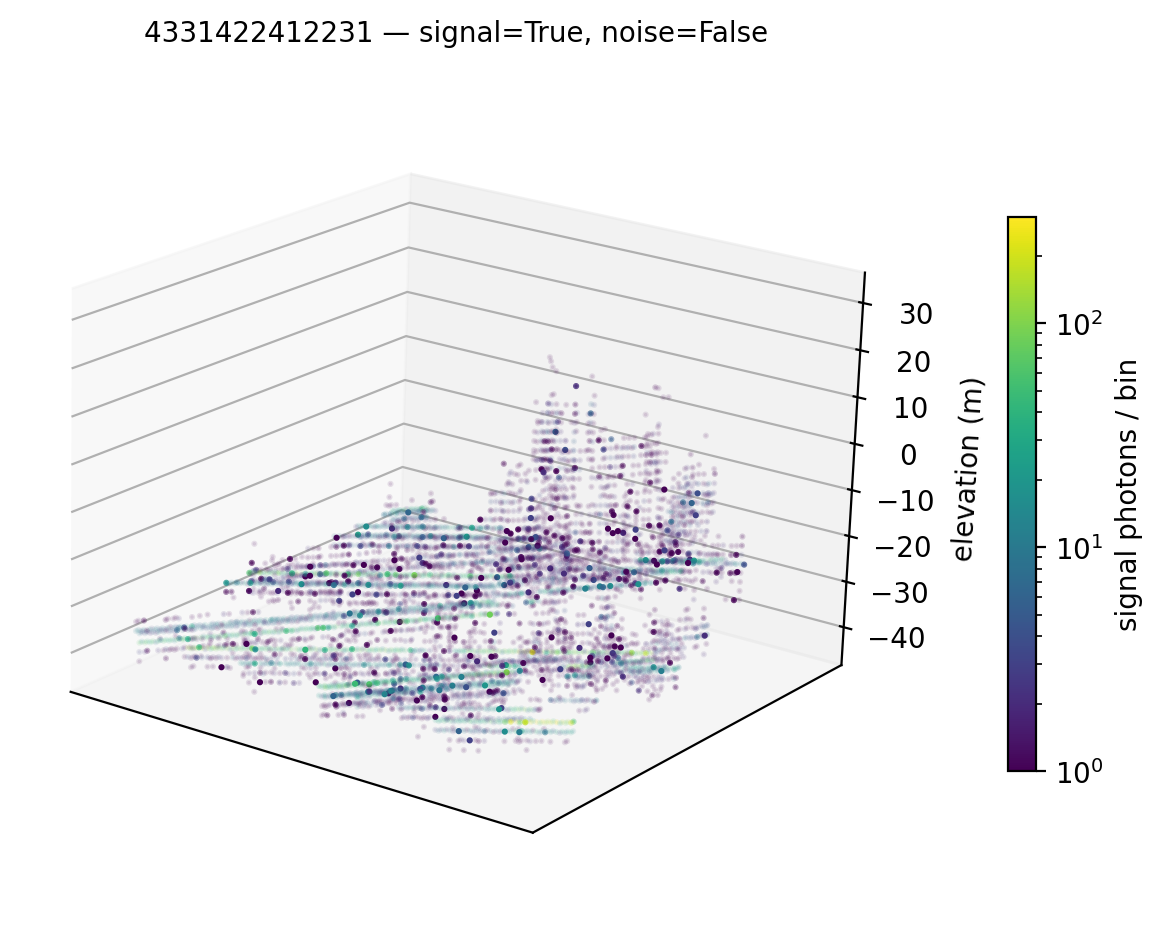

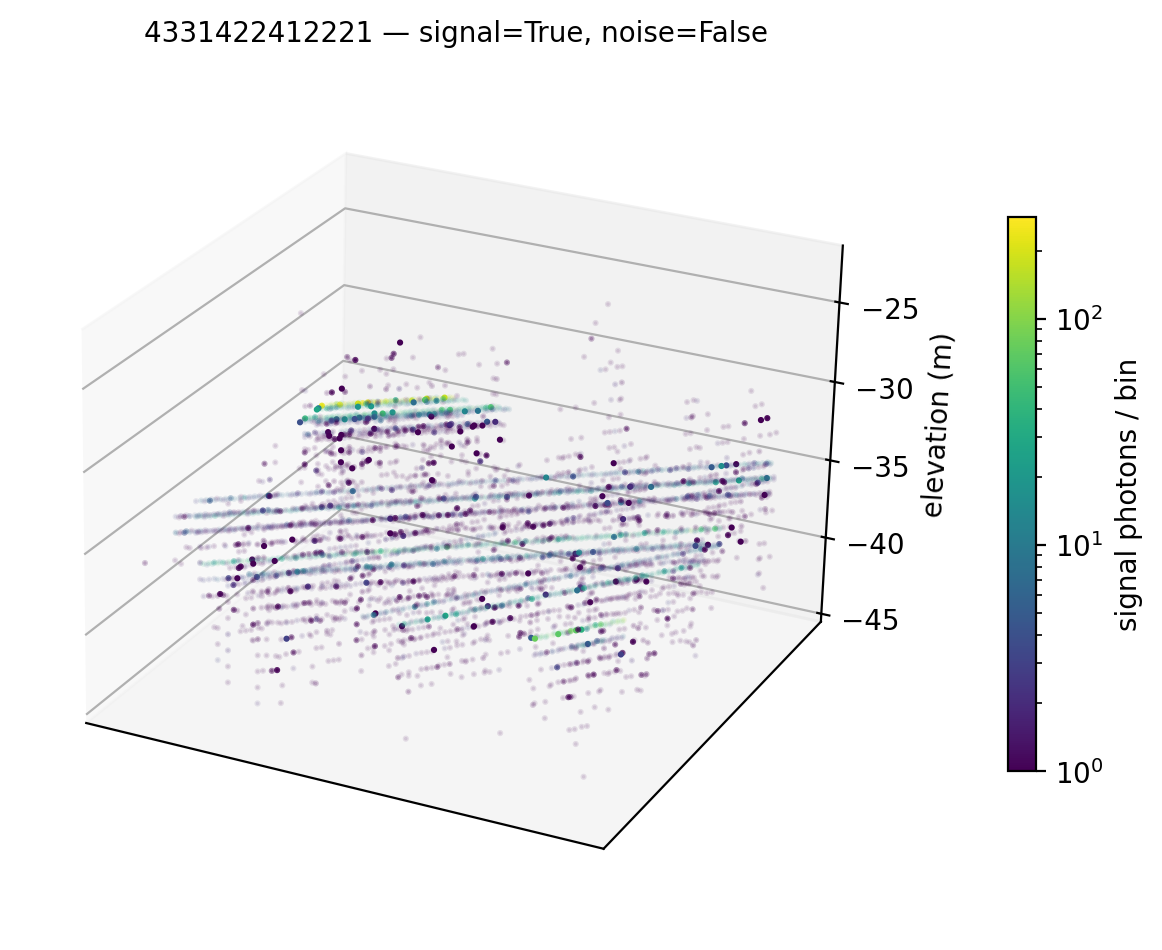

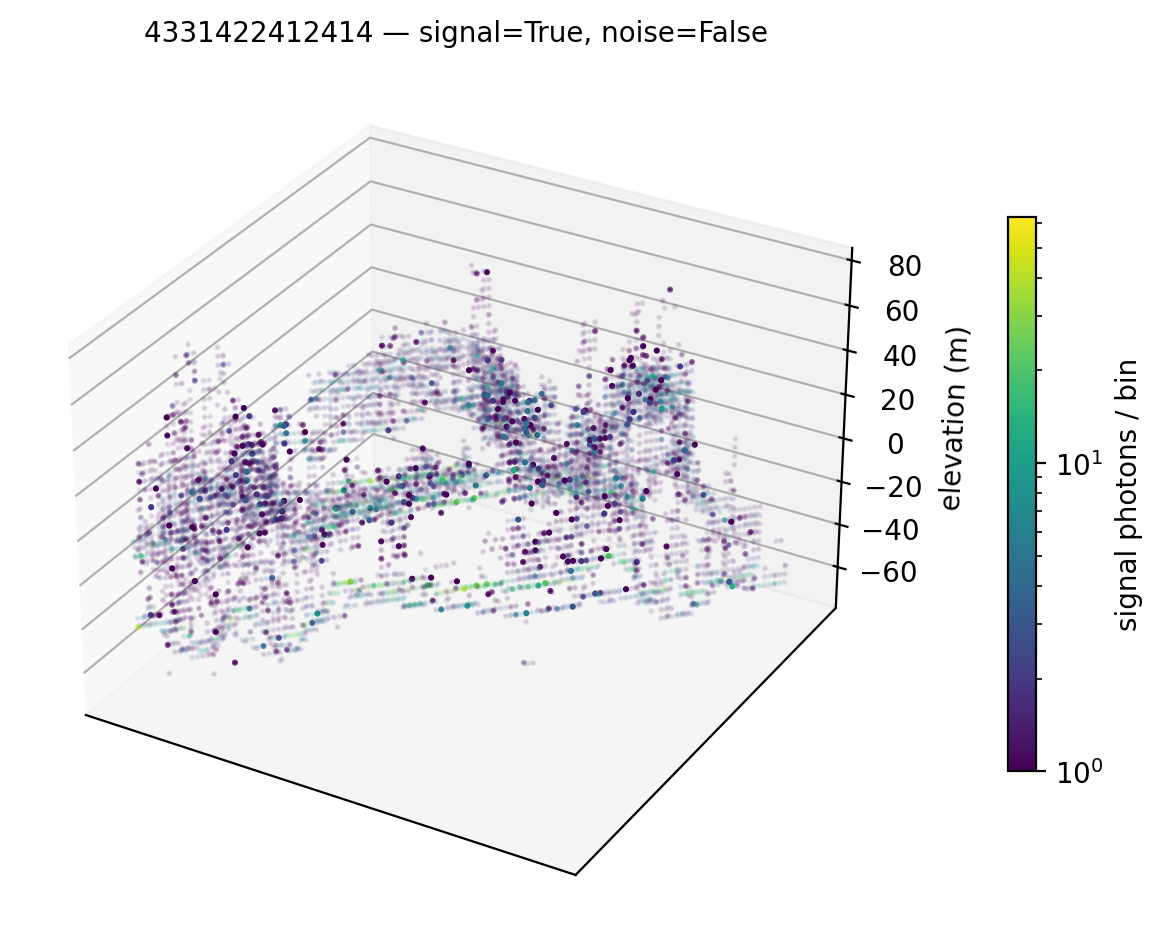

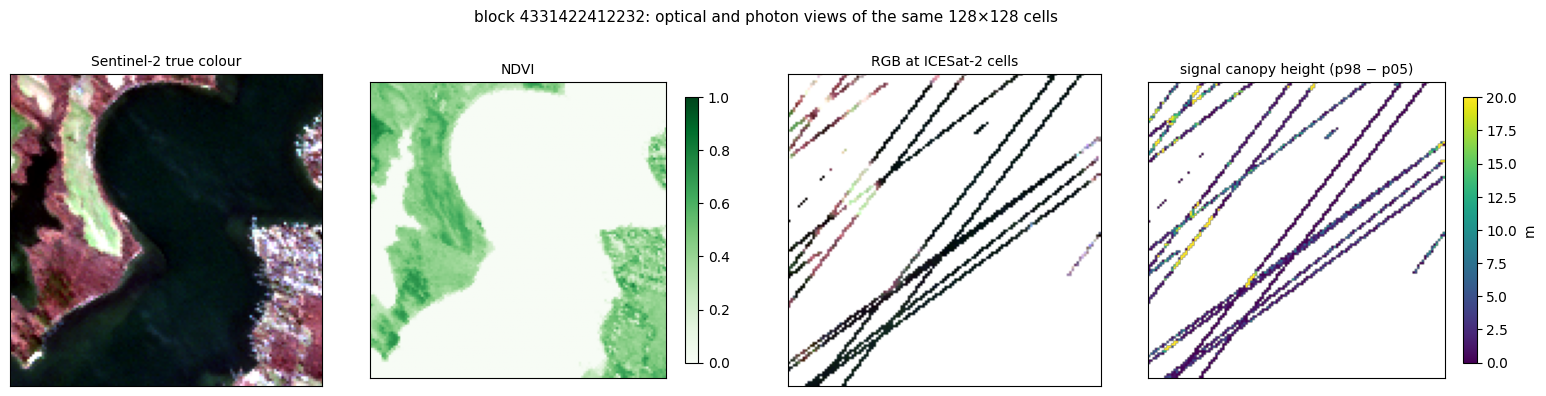

In [19]:
ts_, ms_, (osg, gsg), _ = next(b for b in blocks_sig if b[3] == word)
p05s = percentile_height(ts_, ms_, osg, gsg, 0.05)
p98s = percentile_height(ts_, ms_, osg, gsg, 0.98)
chm = p98s - p05s  # canopy height from SIGNAL photons only
occ = ms_ == 2  # cells with a signal digest


def stretch(band):
    v = band.astype("float64")
    lo, hi = np.percentile(v[v > 0], (2, 98))
    return np.clip((v - lo) / (hi - lo), 0, 1)


refl = np.dstack([stretch(rgb[..., i]) for i in range(3)])
red = rgb[..., 0].astype("float64")
ndvi = np.where(nir + red > 0, (nir - red) / (nir + red), np.nan)
rgb_occ = refl.copy()
rgb_occ[~occ] = 1.0  # optical values only where ICESat-2 sampled: the fusion view
lo, hi = np.nanpercentile(chm, (5, 95))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
axes[0].imshow(refl, origin="lower")
axes[0].set_title("Sentinel-2 true colour", fontsize=10)
im1 = axes[1].imshow(ndvi, origin="lower", cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("NDVI", fontsize=10)
fig.colorbar(im1, ax=axes[1], shrink=0.85)
axes[2].imshow(rgb_occ, origin="lower")
axes[2].set_title("RGB at ICESat-2 cells", fontsize=10)
im3 = axes[3].imshow(chm, origin="lower", cmap="viridis", vmin=lo, vmax=hi)
axes[3].set_title("signal canopy height (p98 − p05)", fontsize=10)
fig.colorbar(im3, ax=axes[3], shrink=0.85, label="m")
for ax in axes:
    ax.set_xticks([]), ax.set_yticks([])
fig.suptitle(f"block {morton_decimal(word)}: optical and photon views of the same 128×128 cells", y=1.03, fontsize=11)
plt.tight_layout()

## Timings

In [20]:
(OUT / "timings_read.json").write_text(json.dumps(timings, indent=2))
units = {
    "one shard: 128x128x64 tensor read": 64,
    "signal stratum: same shard, same blocks": len(blocks_sig),
    "noise stratum: same shard": len(blocks_noise) if "blocks_noise" in dir() else None,
    "all shards: HHDC sweep": len(sweep),
    "one tensor: subtree-restricted read": 1,
    "read_cell: one digest (2 ranged GETs)": 1,
}
df = pd.Series(timings, name="seconds").to_frame()
df["tensors"] = pd.Series({k: v for k, v in units.items() if v})
df["s_per_tensor"] = (df.seconds / df.tensors).round(3)
df

,seconds,tensors,s_per_tensor
open_hive: discover + assemble,4.40,NaN,NaN
one shard: 128x128x64 tensor read,6.22,64.0,0.097
one tensor: subtree-restricted read,1.47,1.0,1.470
"signal stratum: same shard, same blocks",5.73,64.0,0.090
all shards: HHDC sweep,29.76,256.0,0.116
noise stratum: same shard,6.31,64.0,0.099
"open_hive: S2 (time, cells) store",2.32,NaN,NaN
S2: cloud screen + block read,2.59,NaN,NaN
